In [ ]:
import numpy as np
from keras.datasets import mnist
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os

# Define the path to your folder in Google Drive
train_dir = '/content/drive/MyDrive/flowers/'


In [ ]:
img_width, img_height = 200,200

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255,
    rotation_range=3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2, #theo chiều chéo
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
train_generator=train_datagen.flow_from_directory (
    train_dir,
    target_size=(img_width, img_height),
    batch_size=32,
    class_mode='categorical' #chia nhiều nhóm (2 là binary)
)

Found 4317 images belonging to 5 classes.


In [ ]:
model3 = Sequential([
    Conv2D(32,(3,3), activation='relu', input_shape=(img_width,img_height,3)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Conv2D(128,(3,3), activation='relu', padding='same'),
    MaxPooling2D((2,2)),
    Flatten(), # Flatten the output of the convolutional layers
    Dense(128, activation='relu'), # Example Dense layer
    Dropout(0.5), # Example Dropout layer
    Dense(train_generator.num_classes, activation='softmax') # Final Dense layer for classification
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model3.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])
model3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 73728)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     9,437,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,531,205 (36.36 MB)

 Trainable params: 9,531,205 (36.36 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs_num=40
history3=model3.fit(train_generator,epochs=epochs_num)



Epoch 1/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 874s 6s/step - accuracy: 0.4051 - loss: 1.3929
Epoch 2/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 63s 466ms/step - accuracy: 0.5490 - loss: 1.1251
Epoch 3/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 81s 459ms/step - accuracy: 0.6018 - loss: 0.9976
Epoch 4/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 61s 452ms/step - accuracy: 0.6430 - loss: 0.9419
Epoch 5/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 63s 469ms/step - accuracy: 0.6498 - loss: 0.9095
Epoch 6/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 61s 452ms/step - accuracy: 0.6759 - loss: 0.8562
Epoch 7/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 61s 450ms/step - accuracy: 0.6880 - loss: 0.8451
Epoch 8/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 61s 450ms/step - accuracy: 0.6970 - loss: 0.8109
Epoch 9/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 61s 453ms/step - accuracy: 0.7019 - loss: 0.7794
Epoch 10/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 60s 447ms/step - accuracy: 0.7091 - loss: 0.7620
Epoch 11/40
135/135 ━━━━━━━━━━━━━━━━━━━━ 61s 451ms/step - accuracy: 0.7239 - loss: 0.7472
Epoch 12/40
135/135 ━

In [ ]:
model3.save('model3.h5')

from google.colab import files
files.download('model3.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

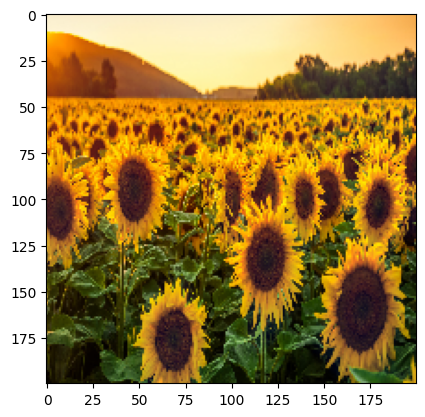

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Hoa tiên đoán: sunflower


In [ ]:
from keras.utils import load_img
from keras.models import load_model # Added import for load_model

model3 = load_model('model3.h5') # Load the model to define it in the current session
path ='Untitled-design-16.png'

img2=load_img(path, target_size=(img_width, img_height))
plt.imshow(img2)
plt.show()

img2=np.array(img2)
img2=img2.reshape(1,img_width,img_height,3)
img2=img2.astype('float32')/255

predictions=np.argmax(model3.predict(img2))

#Anh xa toi ten nguoi
class_lables={v:k for k, v in train_generator.class_indices.items()}
person_name=class_lables[predictions]
print(f"Hoa tiên đoán: {person_name}")